# 1. IMPORT LIBRARIES + DATASET

In [38]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
lending = pd.read_csv("Data_Lending.csv")

# 2. FIRST GLANCE

In [40]:
# 5 dòng đầu tiên
lending.head()

,MONTH,COUNT_OF_LOAN,AVG_LOAN_AMOUNT,CUSTOMER_NUMBER
0,1/31/2019,1,15000000.0,811795
1,2/28/2019,1,13450000.0,811795
2,4/30/2019,1,14169673.0,811795
3,3/31/2019,1,12901665.0,811795
4,9/30/2019,1,13274815.0,811795


In [41]:
# 10 dòng ngẫu nhiên
lending.sample(10)

,MONTH,COUNT_OF_LOAN,AVG_LOAN_AMOUNT,CUSTOMER_NUMBER
576307,12/31/2019,1,46830400.0,718949
91015,9/30/2019,1,321120000.0,560522
426851,10/31/2019,1,15869802.0,591639
191210,7/31/2019,1,766667000.0,153226
296820,7/31/2019,1,600000000.0,794667
58878,3/31/2019,1,273332000.0,968801
382163,8/31/2019,1,996874000.0,513087
513210,7/31/2019,1,150000000.0,973064
386288,11/30/2019,1,249960000.0,672940
174428,5/31/2019,1,4129032.0,348198


In [42]:
# Mô tả dữ liệu
print("--- DESCRIPTION ---")
lending.describe()

--- DESCRIPTION ---


,COUNT_OF_LOAN,AVG_LOAN_AMOUNT,CUSTOMER_NUMBER
count,576431.000000,5.764310e+05,576431.000000
mean,1.133591,4.675963e+08,501365.853093
std,0.569547,1.266526e+09,288669.979794
min,1.000000,1.000000e+00,7.000000
25%,1.000000,7.510252e+07,251027.000000
50%,1.000000,3.451380e+08,500858.000000
75%,1.000000,5.606695e+08,752240.000000
max,121.000000,2.979329e+11,999982.000000


In [43]:
# Thông tin cơ bản
print("--- INFORMATION ---")
lending.info()

--- INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576431 entries, 0 to 576430
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   MONTH            576431 non-null  object 
 1   COUNT_OF_LOAN    576431 non-null  int64  
 2   AVG_LOAN_AMOUNT  576431 non-null  float64
 3   CUSTOMER_NUMBER  576431 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 17.6+ MB


In [44]:
# Kích thước
print("--- SHAPE ----")
print(f"Số dòng: {lending.shape[0]} dòng")
print(f"Số cột: {lending.shape[1]} cột")

--- SHAPE ----
Số dòng: 576431 dòng
Số cột: 4 cột


In [45]:
# Kiểm tra dữ liệu thiếu
print("--- CHECK MISSING VALUES ----")
lending.isna().sum()

--- CHECK MISSING VALUES ----


MONTH              0
COUNT_OF_LOAN      0
AVG_LOAN_AMOUNT    0
CUSTOMER_NUMBER    0
dtype: int64

# 3. DATA CLEANING

Trước hết cứ là chuẩn hoá kiểu dữ liệu

In [46]:
lending["MONTH"] = pd.to_datetime(lending["MONTH"])
lending = lending.sort_values(["CUSTOMER_NUMBER", "MONTH"])
lending.head(10)

,MONTH,COUNT_OF_LOAN,AVG_LOAN_AMOUNT,CUSTOMER_NUMBER
449765,2019-07-31,1,285166000.0,7
449762,2019-08-31,1,280332000.0,7
449763,2019-09-30,1,275498000.0,7
449766,2019-10-31,1,270664000.0,7
449767,2019-11-30,1,265830000.0,7
449764,2019-12-31,1,260996000.0,7
541054,2019-06-30,1,31794135.0,8
541057,2019-07-31,1,32018240.0,8
541055,2019-08-31,1,32018240.0,8
541056,2019-09-30,1,27033592.0,8


## 3.1. Cắt ngưỡng Observation Window

In [47]:
cutoff_date = pd.Timestamp("2019-10-01")

lending_obs = lending[lending["MONTH"] < cutoff_date].copy()
lending_obs

,MONTH,COUNT_OF_LOAN,AVG_LOAN_AMOUNT,CUSTOMER_NUMBER
449765,2019-07-31,1,285166000.0,7
449762,2019-08-31,1,280332000.0,7
449763,2019-09-30,1,275498000.0,7
541054,2019-06-30,1,31794135.0,8
541057,2019-07-31,1,32018240.0,8
...,...,...,...,...
314691,2019-07-31,1,109999998.0,999953
314692,2019-08-31,1,108333331.0,999953
314688,2019-09-30,1,106666664.0,999953
121594,2019-08-31,1,45810000.0,999982


## 3.1.1. Xử lý outlier AVG_LOAN_AMOUNT

AVG_LOAN_AMOUNT bị lệch phải rất mạnh (median ~345 triệu nhưng max ~298 tỷ). Nếu để nguyên, các giá trị cực đoan này sẽ kéo lệch MAX_HIST_LOAN_AMOUNT và đặc biệt MEAN_HIST_LOAN_AMOUNT của khách hàng bị ảnh hưởng.

Mình winsorize (cap) tại percentile 99.5% **tính trên chính observation window (lending_obs)** để không bị leak thông tin từ performance window.

In [48]:
cap_threshold = lending_obs["AVG_LOAN_AMOUNT"].quantile(0.995)
n_capped = (lending_obs["AVG_LOAN_AMOUNT"] > cap_threshold).sum()

lending_obs["AVG_LOAN_AMOUNT_CAPPED"] = lending_obs["AVG_LOAN_AMOUNT"].clip(upper=cap_threshold)

print(f"Ngưỡng cap (percentile 99.5%): {cap_threshold:,.0f}")
print(f"Số dòng bị cap: {n_capped} / {len(lending_obs)} ({n_capped/len(lending_obs):.3%})")

Ngưỡng cap (percentile 99.5%): 3,226,669,860
Số dòng bị cap: 1616 / 323108 (0.500%)


Minh hoạ phân phối AVG_LOAN_AMOUNT trước/sau khi log-transform, để thấy rõ vì sao nên thêm bản log song song với bản gốc.

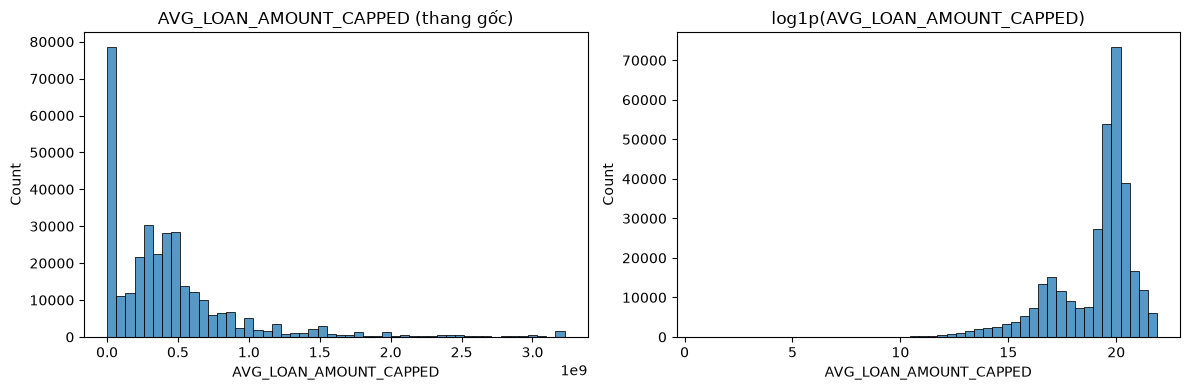

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(lending_obs["AVG_LOAN_AMOUNT_CAPPED"], bins=50, ax=axes[0])
axes[0].set_title("AVG_LOAN_AMOUNT_CAPPED (thang gốc)")

sns.histplot(np.log1p(lending_obs["AVG_LOAN_AMOUNT_CAPPED"]), bins=50, ax=axes[1])
axes[1].set_title("log1p(AVG_LOAN_AMOUNT_CAPPED)")

plt.tight_layout()
plt.show()

## 3.2. Trích xuất snapshot

In [50]:
idx_latest_lend = lending_obs.groupby("CUSTOMER_NUMBER")["MONTH"].idxmax()
feat_lending_snapshot = lending_obs.loc[idx_latest_lend, ["CUSTOMER_NUMBER", "COUNT_OF_LOAN", "AVG_LOAN_AMOUNT_CAPPED"]].copy()
feat_lending_snapshot.rename(columns = {
    "COUNT_OF_LOAN": "LATEST_LOAN_COUNT",
    "AVG_LOAN_AMOUNT_CAPPED": "LATEST_AVG_LOAN_AMOUNT"
}, inplace = True)

# Log-transform (giữ song song với bản gốc để tuỳ model sau này lựa chọn dùng cột nào)
feat_lending_snapshot["LOG_LATEST_AVG_LOAN_AMOUNT"] = np.log1p(feat_lending_snapshot["LATEST_AVG_LOAN_AMOUNT"])

# Lưu ý: cột này hiện tại luôn = 1 vì lending_obs chỉ chứa các dòng khách CÓ vay (COUNT_OF_LOAN >= 1).
# Nó chỉ thực sự có ý nghĩa phân biệt sau khi lending_feature_table được outer-merge với
# bảng khách hàng tổng (bao gồm cả khách không phát sinh khoản vay nào trong observation window).
feat_lending_snapshot["HAS_ACTIVE_LOAN_OBS"] = (feat_lending_snapshot["LATEST_LOAN_COUNT"] > 0).astype(int)
feat_lending_snapshot.head()

,CUSTOMER_NUMBER,LATEST_LOAN_COUNT,LATEST_AVG_LOAN_AMOUNT,LOG_LATEST_AVG_LOAN_AMOUNT,HAS_ACTIVE_LOAN_OBS
449763,7,1,2.754980e+08,19.434091,1
541056,8,1,2.703359e+07,17.112591,1
556379,14,1,1.886791e+07,16.752973,1
340871,16,2,1.500000e+09,21.128731,1
71871,36,1,3.385700e+08,19.640241,1


## 3.2. Trích xuất lịch sử và tăng trưởng

In [51]:
lending_history = lending_obs.groupby("CUSTOMER_NUMBER").agg(
    LOAN_ACTIVE_MONTHS = ("MONTH", "nunique"),
    MAX_HIST_LOAN_COUNT = ("COUNT_OF_LOAN", "max"),
    MAX_HIST_LOAN_AMOUNT = ("AVG_LOAN_AMOUNT_CAPPED", "max"),
    MEAN_HIST_LOAN_AMOUNT = ("AVG_LOAN_AMOUNT_CAPPED", "mean")
).reset_index()

# Log-transform song song với bản gốc (phân phối lệch phải mạnh)
lending_history["LOG_MAX_HIST_LOAN_AMOUNT"] = np.log1p(lending_history["MAX_HIST_LOAN_AMOUNT"])
lending_history["LOG_MEAN_HIST_LOAN_AMOUNT"] = np.log1p(lending_history["MEAN_HIST_LOAN_AMOUNT"])

first_lend = lending_obs.groupby("CUSTOMER_NUMBER").first().reset_index()
last_lend = lending_obs.groupby("CUSTOMER_NUMBER").last().reset_index()

# Số tháng giữa lần vay đầu và lần vay cuối trong observation window (để chuẩn hoá growth theo thời gian)
months_elapsed = (
    (last_lend["MONTH"].dt.year - first_lend["MONTH"].dt.year) * 12
    + (last_lend["MONTH"].dt.month - first_lend["MONTH"].dt.month)
)
# Tránh chia 0 cho khách chỉ có 1 tháng vay (first == last) -> rate = 0 luôn đúng vì amount_growth cũng = 0
months_elapsed_safe = months_elapsed.replace(0, np.nan)

amount_growth = last_lend["AVG_LOAN_AMOUNT_CAPPED"] - first_lend["AVG_LOAN_AMOUNT_CAPPED"]
count_growth = last_lend["COUNT_OF_LOAN"] - first_lend["COUNT_OF_LOAN"]

# Recency: số tháng từ lần vay gần nhất tới cutoff_date
recency_months = (
    (cutoff_date.year - last_lend["MONTH"].dt.year) * 12
    + (cutoff_date.month - last_lend["MONTH"].dt.month)
)

growth_lend_df = pd.DataFrame({
    "CUSTOMER_NUMBER": first_lend["CUSTOMER_NUMBER"],
    "LOAN_AMOUNT_GROWTH": amount_growth,
    "LOAN_COUNT_GROWTH": count_growth,
    # Tốc độ tăng trưởng/tháng, chuẩn hoá theo số tháng đã trôi qua giữa lần vay đầu và cuối
    "LOAN_AMOUNT_GROWTH_RATE": (amount_growth / months_elapsed_safe).fillna(0),
    "RECENCY_MONTHS": recency_months
})
lending_history = lending_history.merge(growth_lend_df, on = "CUSTOMER_NUMBER", how = "left")
lending_history

,CUSTOMER_NUMBER,LOAN_ACTIVE_MONTHS,MAX_HIST_LOAN_COUNT,MAX_HIST_LOAN_AMOUNT,MEAN_HIST_LOAN_AMOUNT,LOG_MAX_HIST_LOAN_AMOUNT,LOG_MEAN_HIST_LOAN_AMOUNT,LOAN_AMOUNT_GROWTH,LOAN_COUNT_GROWTH,LOAN_AMOUNT_GROWTH_RATE,RECENCY_MONTHS
0,7,3,1,2.851660e+08,2.803320e+08,19.468582,19.451485,-9668000.0,0,-4.834000e+06,1
1,8,4,1,3.201824e+07,3.071605e+07,17.281816,17.240296,-4760543.0,0,-1.586848e+06,1
2,14,3,1,1.886791e+07,1.374540e+07,16.752973,16.436215,348914.0,0,1.744570e+05,1
3,16,1,2,1.500000e+09,1.500000e+09,21.128731,21.128731,0.0,0,0.000000e+00,1
4,36,6,1,3.600000e+08,3.492850e+08,19.701615,19.671399,-21430000.0,0,-4.286000e+06,1
...,...,...,...,...,...,...,...,...,...,...,...
73856,999902,5,1,8.000000e+08,7.833400e+08,20.500122,20.479077,-33320000.0,0,-8.330000e+06,1
73857,999926,5,1,1.600000e+08,1.531210e+08,18.890684,18.846739,-13845524.0,0,-3.461381e+06,1
73858,999928,3,1,2.760000e+08,2.714000e+08,19.435911,19.419104,-9200000.0,0,-4.600000e+06,1
73859,999953,9,1,1.200000e+08,1.133333e+08,18.603002,18.545844,-13333336.0,0,-1.666667e+06,1


## 3.3. Gộp + xử lý missing

`fillna(0)` ở đây hiện chưa tạo ra NaN thực sự (vì feat_lending_snapshot và lending_history cùng xuất phát từ tập khách hàng trong lending_obs), nhưng vẫn giữ lại làm bước phòng thủ cho khi bảng này được outer-merge với bảng khách hàng tổng (bao gồm cả khách không có khoản vay nào) ở notebook tổng hợp sau.

In [52]:
lending_clean = feat_lending_snapshot.merge(lending_history, on = "CUSTOMER_NUMBER", how = "outer").fillna(0)
lending_clean.to_csv("lending_clean.csv", index = False)

print(f"Xử lý xong Lending Features! Kích thước: {lending_clean.shape}")
lending_clean.head()

Xử lý xong Lending Features! Kích thước: (73861, 15)


,CUSTOMER_NUMBER,LATEST_LOAN_COUNT,LATEST_AVG_LOAN_AMOUNT,LOG_LATEST_AVG_LOAN_AMOUNT,HAS_ACTIVE_LOAN_OBS,LOAN_ACTIVE_MONTHS,MAX_HIST_LOAN_COUNT,MAX_HIST_LOAN_AMOUNT,MEAN_HIST_LOAN_AMOUNT,LOG_MAX_HIST_LOAN_AMOUNT,LOG_MEAN_HIST_LOAN_AMOUNT,LOAN_AMOUNT_GROWTH,LOAN_COUNT_GROWTH,LOAN_AMOUNT_GROWTH_RATE,RECENCY_MONTHS
0,7,1,2.754980e+08,19.434091,1,3,1,2.851660e+08,2.803320e+08,19.468582,19.451485,-9668000.0,0,-4.834000e+06,1
1,8,1,2.703359e+07,17.112591,1,4,1,3.201824e+07,3.071605e+07,17.281816,17.240296,-4760543.0,0,-1.586848e+06,1
2,14,1,1.886791e+07,16.752973,1,3,1,1.886791e+07,1.374540e+07,16.752973,16.436215,348914.0,0,1.744570e+05,1
3,16,2,1.500000e+09,21.128731,1,1,2,1.500000e+09,1.500000e+09,21.128731,21.128731,0.0,0,0.000000e+00,1
4,36,1,3.385700e+08,19.640241,1,6,1,3.600000e+08,3.492850e+08,19.701615,19.671399,-21430000.0,0,-4.286000e+06,1
